In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q timm torch torchvision scikit-learn pandas matplotlib seaborn pillow

In [ ]:
import os
import gc
import shutil
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models

import timm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print('Libraries loaded.')

Libraries loaded.


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
# ============================================================
# STEP 1: FIX TEST FOLDER — copy to new location and rename
# 'Natural' -> 'natural' so it matches train/val class names.
# Original test folder is NEVER touched.
# Run this cell only ONCE.
# ============================================================

ORIGINAL_TEST_DIR = '/content/drive/MyDrive/autismemotion_split/test'
FIXED_TEST_DIR    = '/content/drive/MyDrive/autismemotion_split/test_fixed'

# Copy entire test folder to new location
if not os.path.exists(FIXED_TEST_DIR):
    shutil.copytree(ORIGINAL_TEST_DIR, FIXED_TEST_DIR)
    print('Copied test folder to:', FIXED_TEST_DIR)
else:
    print('Fixed folder already exists, skipping copy.')

# Rename 'Natural' -> 'natural' inside the COPY only
natural_wrong = os.path.join(FIXED_TEST_DIR, 'Natural')
natural_fixed = os.path.join(FIXED_TEST_DIR, 'natural')

if os.path.exists(natural_wrong) and not os.path.exists(natural_fixed):
    os.rename(natural_wrong, natural_fixed)
    print("Renamed 'Natural' -> 'natural' inside copied folder.")
else:
    print("'natural' already correct or already renamed.")

# Verify
print('\nFolders in fixed test dir:', sorted(os.listdir(FIXED_TEST_DIR)))

Copied test folder to: /content/drive/MyDrive/autismemotion_split/test_fixed
Renamed 'Natural' -> 'natural' inside copied folder.

Folders in fixed test dir: ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']


In [ ]:
# ============================================================
# STEP 2: PATHS
# ============================================================

# --- TRAIN + VAL  from AUGMENTED data (file 1) --------------
AUG_BASE_DIR  = '/content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset'
AUG_DIR       = os.path.join(AUG_BASE_DIR, 'augmented_400_100_100_v2')

AUG_TRAIN_DIR = os.path.join(AUG_DIR, 'train')   # 400 augmented images
AUG_VAL_DIR   = os.path.join(AUG_DIR, 'val')     # 100 augmented images

# --- TEST  from FIXED COPY of non-augmented data ------------
AUG_TEST_DIR  = '/content/drive/MyDrive/autismemotion_split/test_fixed'  # fixed copy, original untouched

# --- RESULTS output folder ----------------------------------
PROJECT_DIR  = AUG_BASE_DIR
RESULTS_DIR  = os.path.join(PROJECT_DIR, 'results_aug_train_nonaug_test')
os.makedirs(RESULTS_DIR, exist_ok=True)

print('AUG_TRAIN_DIR :', AUG_TRAIN_DIR)
print('AUG_VAL_DIR   :', AUG_VAL_DIR)
print('AUG_TEST_DIR  :', AUG_TEST_DIR)
print('RESULTS_DIR   :', RESULTS_DIR)

AUG_TRAIN_DIR : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/augmented_400_100_100_v2/train
AUG_VAL_DIR   : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/augmented_400_100_100_v2/val
AUG_TEST_DIR  : /content/drive/MyDrive/autismemotion_split/test_fixed
RESULTS_DIR   : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results_aug_train_nonaug_test


In [ ]:
# ============================================================
# STEP 3: HYPERPARAMETERS & TRANSFORM
# ============================================================

IMG_SIZE    = 224
BATCH_SIZE  = 4
NUM_WORKERS = 2
EPOCHS      = 30
LR          = 1e-4

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.95, 1.0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LR={LR}')
print('Transform ready.')

IMG_SIZE=224, BATCH_SIZE=4, EPOCHS=30, LR=0.0001
Transform ready.


In [ ]:
# ============================================================
# STEP 4: DATASETS & DATALOADERS
# ============================================================

# Load all three splits
train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)  # augmented train
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)  # augmented val
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)  # non-augmented test (fixed copy)

# Sanity checks
if train_dataset.classes != val_dataset.classes:
    raise ValueError('Train and val class names do not match!')
if train_dataset.classes != test_dataset.classes:
    raise ValueError('Train and test class names do not match!')

class_names = train_dataset.classes
num_classes = len(class_names)

# Combine train + val for actual model training (same as original augmented notebook)
combined_train_dataset = ConcatDataset([train_dataset, val_dataset])  # 400 + 100 = 500 images

# DataLoaders
train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Class weights (used by some models)
_train_labels        = [label for _, label in train_dataset.samples]
_class_weights_np    = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=_train_labels)
class_weights_tensor = torch.tensor(_class_weights_np, dtype=torch.float)

print('Classes           :', class_names)
print('Number of classes :', num_classes)
print('Train images      :', len(train_dataset),          '(augmented)')
print('Val images        :', len(val_dataset),            '(augmented)')
print('Combined training :', len(combined_train_dataset), '(train + val fed to train_loader)')
print('Test images       :', len(test_dataset),           '(NON-augmented, fixed copy)')

Classes           : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes : 6
Train images      : 2400 (augmented)
Val images        : 600 (augmented)
Combined training : 3000 (train + val fed to train_loader)
Test images       : 130 (NON-augmented, fixed copy)


## Setup Summary

| Loader | Data | Images | Purpose |
|---|---|---|---|
| `train_loader` | Augmented train + val combined | 500 | **Model training** |
| `val_loader` | Augmented val only | 100 | **Validation metrics per epoch** |
| `test_loader` | Non-augmented test (fixed copy) | 15% of raw data | **Final test evaluation only** |

- Original test folder `/autismemotion_split/test` is **untouched**.
- Fixed copy `/autismemotion_split/test_fixed` has `Natural` renamed to `natural`.

**Now paste any model cell from the augmented notebook below and run. No changes needed.**

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


MODEL PARAMETER SUMMARY
Total Params : 37,107,594
Trainable    : 37,107,594



Epoch 1/30: 100%|██████████| 750/750 [19:59<00:00,  1.60s/it]


...


Epoch 28/30
----------------------------------------
Train Loss : 0.4749
Train Acc  : 0.9830
Val Loss   : 0.4632
Val Acc    : 0.9833
Precision  : 0.9839
Recall     : 0.9833
F1 Score   : 0.9835
Time       : 137.98 sec


Epoch 29/30: 100%|██████████| 750/750 [02:10<00:00,  5.76it/s]



Epoch 29/30
----------------------------------------
Train Loss : 0.4847
Train Acc  : 0.9780
Val Loss   : 0.4620
Val Acc    : 0.9833
Precision  : 0.9838
Recall     : 0.9833
F1 Score   : 0.9835
Time       : 138.45 sec


Epoch 30/30: 100%|██████████| 750/750 [02:10<00:00,  5.77it/s]



Epoch 30/30
----------------------------------------
Train Loss : 0.4736
Train Acc  : 0.9830
Val Loss   : 0.4544
Val Acc    : 0.9883
Precision  : 0.9886
Recall     : 0.9883
F1 Score   : 0.9884
Time       : 138.32 sec

TEST RESULTS
Accuracy  : 0.6462
Precision : 0.6895
Recall    : 0.6462
F1 Score  : 0.6444

Classification Report:

              precision    recall  f1-score   support

       anger     0.4091    0.8182    0.5455        11
        fear     0.3846    0.8333    0.5263         6
         joy     0.9608    0.8167    0.8829        60
     natural     0.5833    0.7778    0.6667         9
     sadness     0.4706    0.2424    0.3200        33
    surprise     0.4000    0.5455    0.4615        11

    accuracy                         0.6462       130
   macro avg     0.5347    0.6723    0.5671       130
weighted avg     0.6895    0.6462    0.6444       130



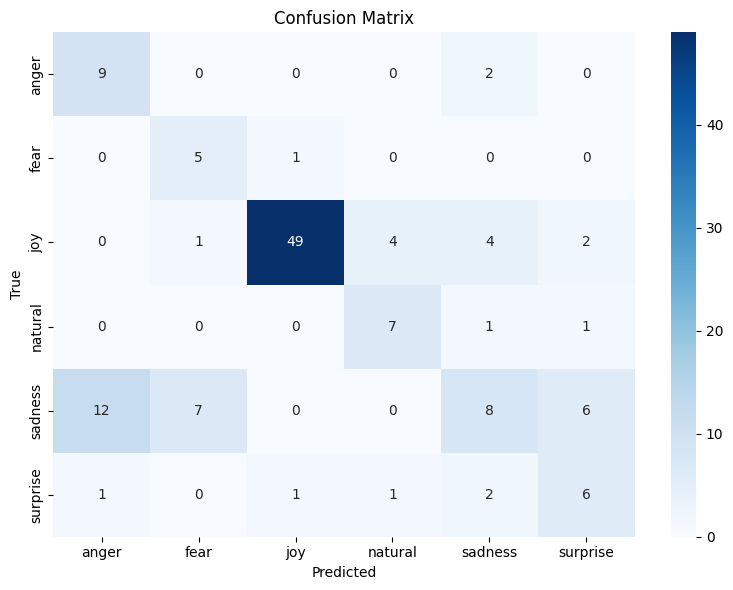

In [ ]:
import os
import gc
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Memory Optimization
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
gc.collect()

# ============================================================
# Dataset
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ============================================================
# Class Weights
# ============================================================

_train_labels = [label for _, label in train_dataset.samples]

_class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=_train_labels
)

class_weights_tensor = torch.tensor(
    _class_weights_np,
    dtype=torch.float
)
# ============================================================
# ASD-MAXFUSIONNET
# Hybrid MaxViT + EfficientNetB0
# Autism Child Emotion Detection
# ============================================================

import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import timm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ============================================================
# CONFIG
# ============================================================

RESULTS_DIR = "./results"

os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 6

CLASS_NAMES = [
    "anger",
    "fear",
    "joy",
    "natural",
    "sadness",
    "surprise"
]

IMAGE_SIZE = 224

# ============================================================
# SE BLOCK
# ============================================================

class SEBlock(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        hidden = max(channels // reduction, 8)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Linear(channels, hidden),

            nn.ReLU(inplace=True),

            nn.Linear(hidden, channels),

            nn.Sigmoid()
        )

    def forward(self, x):

        b, c = x.shape

        y = self.fc(x)

        return x * y

# ============================================================
# ATTENTION FUSION
# ============================================================

class AttentionFusion(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.attn = nn.Sequential(

            nn.Linear(dim * 2, dim),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(dim, dim * 2),

            nn.Sigmoid()
        )

    def forward(self, x1, x2):

        fused = torch.cat(
            [x1, x2],
            dim=1
        )

        weights = self.attn(fused)

        w1, w2 = torch.chunk(
            weights,
            2,
            dim=1
        )

        x1 = x1 * w1
        x2 = x2 * w2

        return torch.cat(
            [x1, x2],
            dim=1
        )

# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2.0,
        reduction="mean"
    ):

        super().__init__()

        self.gamma = gamma

        self.reduction = reduction

    def forward(
        self,
        inputs,
        targets
    ):

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()

        return focal_loss.sum()

# ============================================================
# ASD-MAXFUSIONNET
# ============================================================

class ASDMaxFusionNet(nn.Module):

    def __init__(
        self,
        num_classes=6,
        pretrained=True
    ):

        super().__init__()

        # ====================================================
        # MAXVIT BRANCH
        # ====================================================

        self.maxvit = timm.create_model(
            'maxvit_tiny_tf_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        maxvit_dim = self.maxvit.num_features

        # ====================================================
        # EFFICIENTNET BRANCH
        # ====================================================

        self.efficientnet = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        eff_dim = self.efficientnet.num_features

        # ====================================================
        # FEATURE REFINEMENT
        # ====================================================

        self.maxvit_branch = nn.Sequential(

            nn.Linear(maxvit_dim, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        self.efficient_branch = nn.Sequential(

            nn.Linear(eff_dim, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        # ====================================================
        # SE ATTENTION
        # ====================================================

        self.maxvit_se = SEBlock(512)

        self.efficient_se = SEBlock(512)

        # ====================================================
        # ATTENTION FUSION
        # ====================================================

        self.fusion = AttentionFusion(512)

        # ====================================================
        # CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(1024, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(512, 256),

            nn.LayerNorm(256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # ====================================================
        # MAXVIT FEATURES
        # ====================================================

        maxvit_feat = self.maxvit(x)

        maxvit_feat = self.maxvit_branch(
            maxvit_feat
        )

        maxvit_feat = self.maxvit_se(
            maxvit_feat
        )

        # ====================================================
        # EFFICIENTNET FEATURES
        # ====================================================

        eff_feat = self.efficientnet(x)

        eff_feat = self.efficient_branch(
            eff_feat
        )

        eff_feat = self.efficient_se(
            eff_feat
        )

        # ====================================================
        # FUSION
        # ====================================================

        fused = self.fusion(
            maxvit_feat,
            eff_feat
        )

        # ====================================================
        # CLASSIFICATION
        # ====================================================

        out = self.classifier(fused)

        return out

# ============================================================
# PARAMETER SUMMARY
# ============================================================

def print_parameter_summary(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("\n==============================")

    print("MODEL PARAMETER SUMMARY")

    print("==============================")

    print(f"Total Params : {total:,}")

    print(f"Trainable    : {trainable:,}")

    print("==============================\n")

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_model(
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-4
):

    model = ASDMaxFusionNet(
        num_classes=NUM_CLASSES
    ).to(device)

    print_parameter_summary(model)

    # criterion = FocalLoss()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = torch.amp.GradScaler("cuda")

    best_val_acc = 0.0

    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history = {

        "train_acc": [],
        "val_acc": [],

        "train_loss": [],
        "val_loss": []
    }

    # ========================================================
    # TRAIN LOOP
    # ========================================================

    for epoch in range(epochs):

        start = time.time()

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        train_loss = 0.0

        train_correct = 0

        train_total = 0

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        ):

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            scaler.scale(loss).backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)

            scaler.update()

            _, preds = torch.max(
                outputs,
                1
            )

            train_loss += (
                loss.item() * images.size(0)
            )

            train_correct += torch.sum(
                preds == labels
            ).item()

            train_total += labels.size(0)

        train_epoch_loss = (
            train_loss / train_total
        )

        train_epoch_acc = (
            train_correct / train_total
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_loss = 0.0

        val_correct = 0

        val_total = 0

        all_preds = []

        all_labels = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                with torch.amp.autocast("cuda"):

                    outputs = model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )

                _, preds = torch.max(
                    outputs,
                    1
                )

                val_loss += (
                    loss.item() * images.size(0)
                )

                val_correct += torch.sum(
                    preds == labels
                ).item()

                val_total += labels.size(0)

                all_preds.extend(
                    preds.cpu().numpy()
                )

                all_labels.extend(
                    labels.cpu().numpy()
                )

        val_epoch_loss = (
            val_loss / val_total
        )

        val_epoch_acc = (
            val_correct / val_total
        )

        scheduler.step()

        # ====================================================
        # SAVE HISTORY
        # ====================================================

        history["train_acc"].append(
            train_epoch_acc
        )

        history["val_acc"].append(
            val_epoch_acc
        )

        history["train_loss"].append(
            train_epoch_loss
        )

        history["val_loss"].append(
            val_epoch_loss
        )

        # ====================================================
        # SAVE BEST MODEL
        # ====================================================

        if val_epoch_acc > best_val_acc:

            best_val_acc = val_epoch_acc

            best_weights = copy.deepcopy(
                model.state_dict()
            )

            torch.save(

                model.state_dict(),

                os.path.join(
                    RESULTS_DIR,
                    "best_asd_maxfusionnet.pth"
                )
            )

        # ====================================================
        # METRICS
        # ====================================================

        precision = precision_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        recall = recall_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        f1 = f1_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        end = time.time()

        print("\n========================================")

        print(f"Epoch {epoch+1}/{epochs}")

        print("----------------------------------------")

        print(
            f"Train Loss : {train_epoch_loss:.4f}"
        )

        print(
            f"Train Acc  : {train_epoch_acc:.4f}"
        )

        print(
            f"Val Loss   : {val_epoch_loss:.4f}"
        )

        print(
            f"Val Acc    : {val_epoch_acc:.4f}"
        )

        print(
            f"Precision  : {precision:.4f}"
        )

        print(
            f"Recall     : {recall:.4f}"
        )

        print(
            f"F1 Score   : {f1:.4f}"
        )

        print(
            f"Time       : {(end-start):.2f} sec"
        )

        print("========================================")

    # ========================================================
    # LOAD BEST MODEL
    # ========================================================

    model.load_state_dict(best_weights)

    return model, history

# ============================================================
# TEST FUNCTION
# ============================================================

def evaluate_model(
    model,
    test_loader
):

    model.eval()

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    print("\n================================")

    print("TEST RESULTS")

    print("================================")

    print(f"Accuracy  : {acc:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print("================================")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(

        classification_report(
            all_labels,
            all_preds,
            target_names=CLASS_NAMES,
             digits=4
        )
    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.title("Confusion Matrix")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            RESULTS_DIR,
            "confusion_matrix.png"
        )
    )

    plt.show()

# ============================================================
# RUN TRAINING
# ============================================================

"""
IMPORTANT:

You must already define:

train_loader
val_loader
test_loader

before running this section.
"""

model, history = train_model(

    train_loader=train_loader,

    val_loader=val_loader,

    epochs=30,

    lr=1e-4
)

# ============================================================
# EVALUATION
# ============================================================

evaluate_model(
    model,
    test_loader
)